# Carrier Service Analysis

In [1]:
# Imports
import boto3
from sagemaker import get_execution_role
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [2]:
role = get_execution_role()
bucket = 'json-avalos-ads508'
delog_data_key = 'Delivery_Logistics 2.csv'
dysulog_data_key = 'dynamic_supply_chain_logistics_dataset.csv'
trade_cus_data_key = 'trade_customs_dataset 2.csv'
del_loc = 's3://{}/{}'.format(bucket, delog_data_key)
dyn_loc = 's3://{}/{}'.format(bucket, dysulog_data_key)
trade_loc = 's3://{}/{}'.format(bucket, trade_cus_data_key)

In [3]:
#!pip install openpyxl # dependency
delivery = pd.read_csv(del_loc)
dynamic = pd.read_csv(dyn_loc)
trade = pd.read_csv(trade_loc)

In [4]:
trade.head()

,Shipment_ID,Origin_Country,Destination_Country,Shipment_Date,Estimated_Arrival_Date,Actual_Arrival_Date,Transport_Mode,Carrier_Name,Route_Code,Commodity_Type,...,HS_Code,Document_Status,Compliance_Score,Prior_Offense_Count,Tariff_Category,Route_Risk_Index,Inspection_Type,Delay_Reason,Customs_Delay_Days,Risk_Flag
0,SHP000001,India,China,2022-01-31,2022-02-12,2022-02-15,Air,Carrier_9,R854,Electronics,...,9935.21,Error,0.49,3,Low,0.16,Physical,"Incomplete paperwork, requires manual review",3,1
1,SHP000002,Germany,Brazil,2024-08-31,2024-09-24,2024-09-25,Sea,Carrier_36,R303,Machinery,...,9928.63,Complete,0.76,3,High,0.71,Document,Routine customs clearance without issue,1,1
2,SHP000003,China,Germany,2023-09-28,2023-10-13,2023-10-13,Road,Carrier_10,R320,Automotive,...,2674.21,Missing,0.58,0,Medium,0.52,Document,Incorrect HS code classification,0,0
3,SHP000004,Brazil,China,2024-02-25,2024-03-18,2024-03-21,Sea,Carrier_25,R180,Food,...,5803.90,Error,0.77,2,High,0.14,Physical,"Suspected undervaluation, needs reassessment",3,1
4,SHP000005,India,China,2021-07-22,2021-08-20,2021-08-20,Road,Carrier_6,R975,Pharmaceuticals,...,2654.58,Missing,0.52,3,High,0.51,Document,High-risk commodity flagged for inspection,0,0


In [5]:
trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Shipment_ID             10000 non-null  object 
 1   Origin_Country          10000 non-null  object 
 2   Destination_Country     10000 non-null  object 
 3   Shipment_Date           10000 non-null  object 
 4   Estimated_Arrival_Date  10000 non-null  object 
 5   Actual_Arrival_Date     10000 non-null  object 
 6   Transport_Mode          10000 non-null  object 
 7   Carrier_Name            10000 non-null  object 
 8   Route_Code              10000 non-null  object 
 9   Commodity_Type          10000 non-null  object 
 10  Declared_Value_USD      10000 non-null  float64
 11  Weight_kg               10000 non-null  float64
 12  HS_Code                 10000 non-null  float64
 13  Document_Status         10000 non-null  object 
 14  Compliance_Score        10000 non-null 

In [6]:
trade["Shipment_Date"] = pd.to_datetime(trade["Shipment_Date"])
trade["Estimated_Arrival_Date"] = pd.to_datetime(trade["Estimated_Arrival_Date"])
trade["Actual_Arrival_Date"] = pd.to_datetime(trade["Actual_Arrival_Date"])

trade["Transit_Delay_Days"] = (
    trade["Actual_Arrival_Date"] - trade["Estimated_Arrival_Date"]
).dt.days

trade["Is_Delayed"] = (trade["Transit_Delay_Days"] > 0).astype(int)

In [7]:
trade["Transit_Delay_Days"].describe()

count    10000.000000
mean         2.059500
std          2.234784
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         13.000000
Name: Transit_Delay_Days, dtype: float64

In [8]:
trade["Is_Delayed"].mean()

0.6307

In [9]:
trade["Carrier_Name"].value_counts()

Carrier_Name
Carrier_33    233
Carrier_8     226
Carrier_15    226
Carrier_26    220
Carrier_41    219
Carrier_14    218
Carrier_37    216
Carrier_7     216
Carrier_17    215
Carrier_48    212
Carrier_30    212
Carrier_47    211
Carrier_1     210
Carrier_3     210
Carrier_36    209
Carrier_31    207
Carrier_43    206
Carrier_5     204
Carrier_50    204
Carrier_19    204
Carrier_2     204
Carrier_27    203
Carrier_23    203
Carrier_6     203
Carrier_16    203
Carrier_4     202
Carrier_10    202
Carrier_42    199
Carrier_18    199
Carrier_20    197
Carrier_25    196
Carrier_13    195
Carrier_24    194
Carrier_32    193
Carrier_21    193
Carrier_45    192
Carrier_11    190
Carrier_22    190
Carrier_28    189
Carrier_35    189
Carrier_29    188
Carrier_34    187
Carrier_12    187
Carrier_9     186
Carrier_44    186
Carrier_49    176
Carrier_38    173
Carrier_39    173
Carrier_40    167
Carrier_46    163
Name: count, dtype: int64

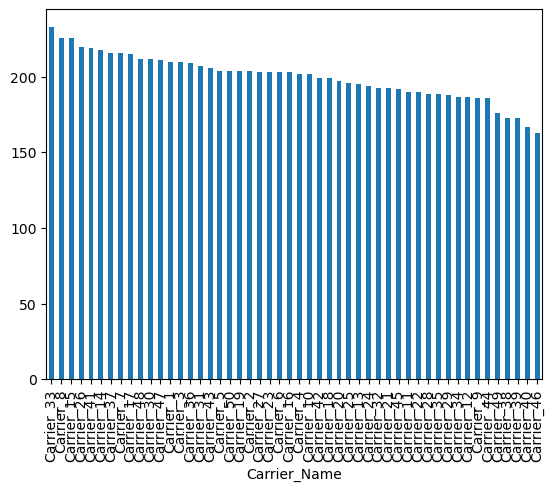

In [10]:
trade["Carrier_Name"].value_counts().plot(kind="bar")
plt.show()

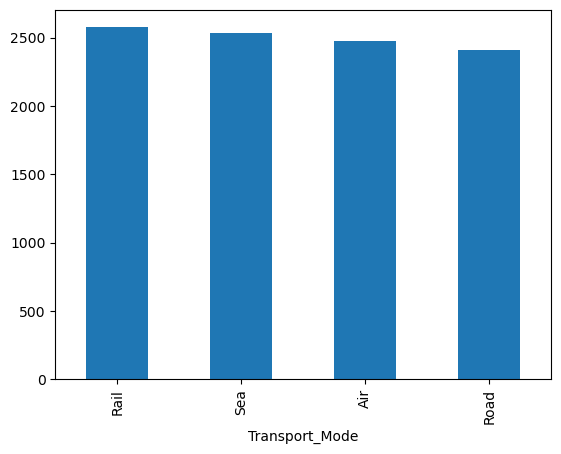

In [11]:
trade["Transport_Mode"].value_counts().plot(kind="bar")
plt.show()

In [12]:
trade["Document_Status"].value_counts()

Document_Status
Missing     3370
Error       3339
Complete    3291
Name: count, dtype: int64

In [13]:
trade["Inspection_Type"].value_counts()

Inspection_Type
Document    3374
Both        3323
Physical    3303
Name: count, dtype: int64

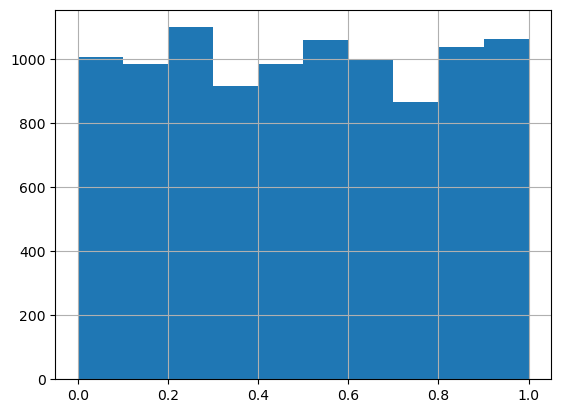

In [14]:
trade["Route_Risk_Index"].hist()
plt.show()

In [15]:
trade.groupby("Carrier_Name")["Transit_Delay_Days"].agg(["mean","median"])
trade.groupby("Carrier_Name")["Is_Delayed"].mean()

Carrier_Name
Carrier_1     0.676190
Carrier_10    0.648515
Carrier_11    0.621053
Carrier_12    0.588235
Carrier_13    0.656410
Carrier_14    0.582569
Carrier_15    0.610619
Carrier_16    0.645320
Carrier_17    0.627907
Carrier_18    0.693467
Carrier_19    0.549020
Carrier_2     0.622549
Carrier_20    0.614213
Carrier_21    0.658031
Carrier_22    0.605263
Carrier_23    0.650246
Carrier_24    0.567010
Carrier_25    0.632653
Carrier_26    0.622727
Carrier_27    0.655172
Carrier_28    0.619048
Carrier_29    0.686170
Carrier_3     0.633333
Carrier_30    0.660377
Carrier_31    0.652174
Carrier_32    0.590674
Carrier_33    0.656652
Carrier_34    0.614973
Carrier_35    0.566138
Carrier_36    0.669856
Carrier_37    0.615741
Carrier_38    0.630058
Carrier_39    0.670520
Carrier_4     0.693069
Carrier_40    0.652695
Carrier_41    0.598174
Carrier_42    0.653266
Carrier_43    0.587379
Carrier_44    0.612903
Carrier_45    0.666667
Carrier_46    0.668712
Carrier_47    0.677725
Carrier_48    0.65094

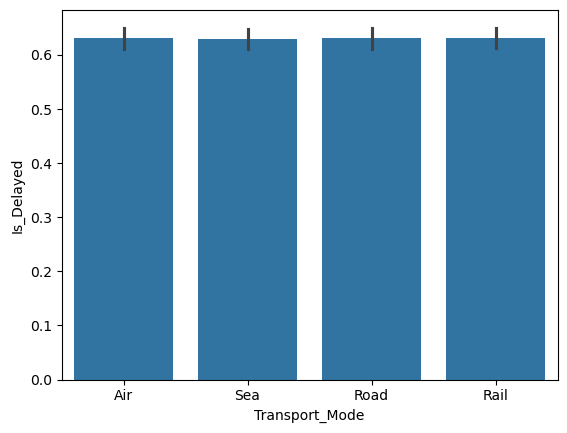

In [16]:
sns.barplot(data=trade, x="Transport_Mode", y="Is_Delayed")
plt.show()

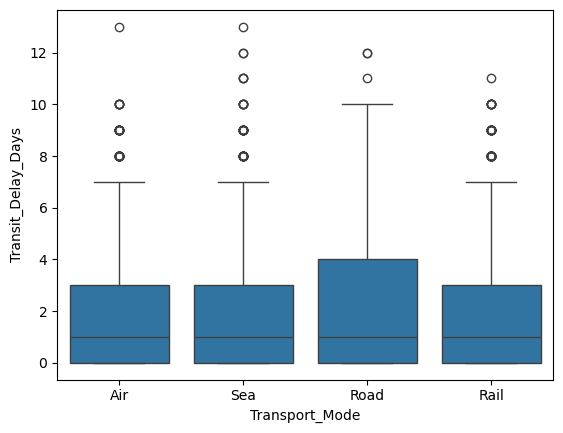

In [17]:
sns.boxplot(data=trade, x="Transport_Mode", y="Transit_Delay_Days")
plt.show()

In [18]:
pd.pivot_table(
    trade,
    values="Is_Delayed",
    index="Carrier_Name",
    columns="Transport_Mode",
    aggfunc="mean"
)

Transport_Mode,Air,Rail,Road,Sea
Carrier_Name,,,,
Carrier_1,0.704545,0.660714,0.655172,0.692308
Carrier_10,0.650000,0.619048,0.613636,0.696429
Carrier_11,0.603774,0.720000,0.604651,0.545455
Carrier_12,0.589744,0.500000,0.638889,0.637931
Carrier_13,0.586957,0.571429,0.782609,0.702128
Carrier_14,0.612903,0.537037,0.488372,0.661017
Carrier_15,0.610169,0.592593,0.660714,0.578947
Carrier_16,0.685185,0.608696,0.620000,0.660377
Carrier_17,0.620000,0.642857,0.531915,0.693548


In [19]:
pd.pivot_table(
    trade,
    values="Is_Delayed",
    index="Carrier_Name",
    columns="Inspection_Type",
    aggfunc="mean"
)


Inspection_Type,Both,Document,Physical
Carrier_Name,,,
Carrier_1,0.703125,0.685714,0.644737
Carrier_10,0.681159,0.623377,0.642857
Carrier_11,0.634921,0.634921,0.593750
Carrier_12,0.516667,0.609375,0.634921
Carrier_13,0.661765,0.633803,0.678571
Carrier_14,0.538462,0.535714,0.681159
Carrier_15,0.638554,0.558442,0.636364
Carrier_16,0.723684,0.623188,0.568966
Carrier_17,0.649351,0.691176,0.542857


Observations

In [20]:
carrier_delay_rates = (
    trade.groupby("Carrier_Name")["Is_Delayed"]
         .mean()
         .sort_values(ascending=False)
)

carrier_delay_rates

Carrier_Name
Carrier_18    0.693467
Carrier_4     0.693069
Carrier_29    0.686170
Carrier_47    0.677725
Carrier_1     0.676190
Carrier_39    0.670520
Carrier_36    0.669856
Carrier_46    0.668712
Carrier_45    0.666667
Carrier_30    0.660377
Carrier_21    0.658031
Carrier_5     0.656863
Carrier_33    0.656652
Carrier_13    0.656410
Carrier_27    0.655172
Carrier_42    0.653266
Carrier_40    0.652695
Carrier_31    0.652174
Carrier_48    0.650943
Carrier_23    0.650246
Carrier_10    0.648515
Carrier_16    0.645320
Carrier_3     0.633333
Carrier_25    0.632653
Carrier_38    0.630058
Carrier_17    0.627907
Carrier_26    0.622727
Carrier_2     0.622549
Carrier_50    0.622549
Carrier_11    0.621053
Carrier_49    0.619318
Carrier_28    0.619048
Carrier_37    0.615741
Carrier_8     0.615044
Carrier_34    0.614973
Carrier_20    0.614213
Carrier_44    0.612903
Carrier_15    0.610619
Carrier_22    0.605263
Carrier_41    0.598174
Carrier_6     0.596059
Carrier_7     0.592593
Carrier_32    0.59067

In [22]:
carrier_delay_rates = (
    trade.groupby("Carrier_Name")["Is_Delayed"]
         .mean()
         .sort_values(ascending=False)
)

carrier_delay_rates

carrier_delay_rates.head(5)

Carrier_Name
Carrier_18    0.693467
Carrier_4     0.693069
Carrier_29    0.686170
Carrier_47    0.677725
Carrier_1     0.676190
Name: Is_Delayed, dtype: float64

In [23]:
route_delay_rates = (
    trade.groupby("Route_Code")["Is_Delayed"]
         .mean()
         .sort_values(ascending=False)
)

route_delay_rates
route_delay_rates.head(5)

Route_Code
R664    1.0
R823    1.0
R685    1.0
R584    1.0
R720    1.0
Name: Is_Delayed, dtype: float64

In [29]:
trade[trade['Route_Code'] == "R685"]

,Shipment_ID,Origin_Country,Destination_Country,Shipment_Date,Estimated_Arrival_Date,Actual_Arrival_Date,Transport_Mode,Carrier_Name,Route_Code,Commodity_Type,...,Compliance_Score,Prior_Offense_Count,Tariff_Category,Route_Risk_Index,Inspection_Type,Delay_Reason,Customs_Delay_Days,Risk_Flag,Transit_Delay_Days,Is_Delayed
383,SHP000384,Japan,UK,2023-06-29,2023-07-12,2023-07-16,Rail,Carrier_12,R685,Pharmaceuticals,...,0.96,2,Low,0.05,Both,Tariff dispute pending resolution,4,2,4,1
2242,SHP002243,Germany,UAE,2019-06-02,2019-06-10,2019-06-14,Rail,Carrier_15,R685,Food,...,0.92,0,Low,0.58,Both,Routine customs clearance without issue,4,2,4,1
2811,SHP002812,Australia,India,2022-08-25,2022-09-22,2022-09-27,Sea,Carrier_33,R685,Pharmaceuticals,...,0.98,5,Medium,0.81,Physical,High-risk commodity flagged for inspection,5,2,5,1
7196,SHP007197,South Africa,Brazil,2023-10-13,2023-10-21,2023-10-26,Rail,Carrier_23,R685,Pharmaceuticals,...,0.41,4,Low,0.43,Both,"Suspected undervaluation, needs reassessment",5,2,5,1
9142,SHP009143,India,Brazil,2023-05-19,2023-06-12,2023-06-14,Rail,Carrier_5,R685,Food,...,0.51,0,Low,0.06,Document,"Incomplete paperwork, requires manual review",2,1,2,1
9860,SHP009861,UK,Brazil,2019-11-12,2019-12-10,2019-12-11,Road,Carrier_45,R685,Electronics,...,0.81,1,Low,0.37,Physical,High-risk commodity flagged for inspection,1,1,1,1
